In [155]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

model_results = {}

In [156]:
# ============= Load data =============
print("="*50)
print("LOADING PREPROCESSED DATA")
print("="*50)


X_train = pd.read_csv('../data/X_train_normalized.csv')
X_test = pd.read_csv('../data/X_test_normalized.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

# Convert y to a Series (instead of a DataFrame)
y_train = y_train.squeeze() if y_train.shape[1] == 1 else y_train
y_test = y_test.squeeze() if y_test.shape[1] == 1 else y_test

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("="*50)


LOADING PREPROCESSED DATA
X_train shape: (8880, 207)
X_test shape: (2220, 207)
y_train shape: (8880,)
y_test shape: (2220,)


In [157]:
# 1. Linear Regression
print("\n" + "="*50)
print("1. Ridge Regression (Linear with Regularization)")
print("="*50)

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
y_train_pred = ridge_model.predict(X_train)
y_test_pred = ridge_model.predict(X_test)

model_results['Ridge Regression'] = {
    'Train R²': r2_score(y_train, y_train_pred),
    'Test R²': r2_score(y_test, y_test_pred),
    'Train MSE': mean_squared_error(y_train, y_train_pred),
    'Test MSE': mean_squared_error(y_test, y_test_pred),
    'Train MAE': mean_absolute_error(y_train, y_train_pred),
    'Test MAE': mean_absolute_error(y_test, y_test_pred)
}

print(f"Train R²: {model_results['Ridge Regression']['Train R²']:.4f}")
print(f"Test R²: {model_results['Ridge Regression']['Test R²']:.4f}")
print(f"Test MAE: {model_results['Ridge Regression']['Test MAE']:.4f}")


1. Ridge Regression (Linear with Regularization)
Train R²: 0.9814
Test R²: 0.9792
Test MAE: 0.2584


In [158]:
# 2. Random Forest 
print("\n" + "="*50)
print("2. Random Forest Regressor (Optimized)")
print("="*50)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=15,
    min_samples_leaf=5,
    max_features='sqrt',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

model_results['Random Forest'] = {
    'Train R²': r2_score(y_train, y_train_pred),
    'Test R²': r2_score(y_test, y_test_pred),
    'Train MSE': mean_squared_error(y_train, y_train_pred),
    'Test MSE': mean_squared_error(y_test, y_test_pred),
    'Train MAE': mean_absolute_error(y_train, y_train_pred),
    'Test MAE': mean_absolute_error(y_test, y_test_pred)
}

print(f"Train R²: {model_results['Random Forest']['Train R²']:.4f}")
print(f"Test R²: {model_results['Random Forest']['Test R²']:.4f}")
print(f"Test MAE: {model_results['Random Forest']['Test MAE']:.4f}")
print(f"OOB Score: {rf_model.oob_score_:.4f}")


2. Random Forest Regressor (Optimized)
Train R²: 0.9709
Test R²: 0.9630
Test MAE: 0.3798
OOB Score: 0.9617


In [159]:
# 3. Gradient Boosting 
print("\n" + "="*50)
print("3. Gradient Boosting Regressor (Optimized)")
print("="*50)

gbr_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

gbr_model.fit(X_train, y_train)
y_train_pred = gbr_model.predict(X_train)
y_test_pred = gbr_model.predict(X_test)

model_results['Gradient Boosting'] = {
    'Train R²': r2_score(y_train, y_train_pred),
    'Test R²': r2_score(y_test, y_test_pred),
    'Train MSE': mean_squared_error(y_train, y_train_pred),
    'Test MSE': mean_squared_error(y_test, y_test_pred),
    'Train MAE': mean_absolute_error(y_train, y_train_pred),
    'Test MAE': mean_absolute_error(y_test, y_test_pred)
}

print(f"Train R²: {model_results['Gradient Boosting']['Train R²']:.4f}")
print(f"Test R²: {model_results['Gradient Boosting']['Test R²']:.4f}")
print(f"Test MAE: {model_results['Gradient Boosting']['Test MAE']:.4f}")


3. Gradient Boosting Regressor (Optimized)
Train R²: 0.9912
Test R²: 0.9885
Test MAE: 0.2156


In [160]:
# ============= 7. Display comparison =============
print("\n" + "="*50)
print("FINAL MODEL COMPARISON")
print("="*50)

comparison_df = pd.DataFrame(model_results).T
print(comparison_df.round(4))



FINAL MODEL COMPARISON
                   Train R²  Test R²  Train MSE  Test MSE  Train MAE  Test MAE
Ridge Regression     0.9814   0.9792     0.1167    0.1392     0.2433    0.2584
Random Forest        0.9709   0.9630     0.1825    0.2477     0.3236    0.3798
Gradient Boosting    0.9912   0.9885     0.0554    0.0769     0.1871    0.2156


In [161]:
# ============= 8. Overfitting check =============
print("\n" + "="*50)
print("OVERFITTING CHECK (Train-Test Difference)")
print("="*50)

for model_name in model_results:
    diff_r2 = model_results[model_name]['Train R²'] - model_results[model_name]['Test R²']
    status = "✓ Good" if diff_r2 < 0.05 else "⚠️ Possible Overfitting" if diff_r2 < 0.1 else "❌ Overfitting"
    print(f"{model_name:20} | R² diff: {diff_r2:.4f} | {status}")


OVERFITTING CHECK (Train-Test Difference)
Ridge Regression     | R² diff: 0.0022 | ✓ Good
Random Forest        | R² diff: 0.0079 | ✓ Good
Gradient Boosting    | R² diff: 0.0026 | ✓ Good



🏆 Best Model: Gradient Boosting (Test R² = 0.9885)


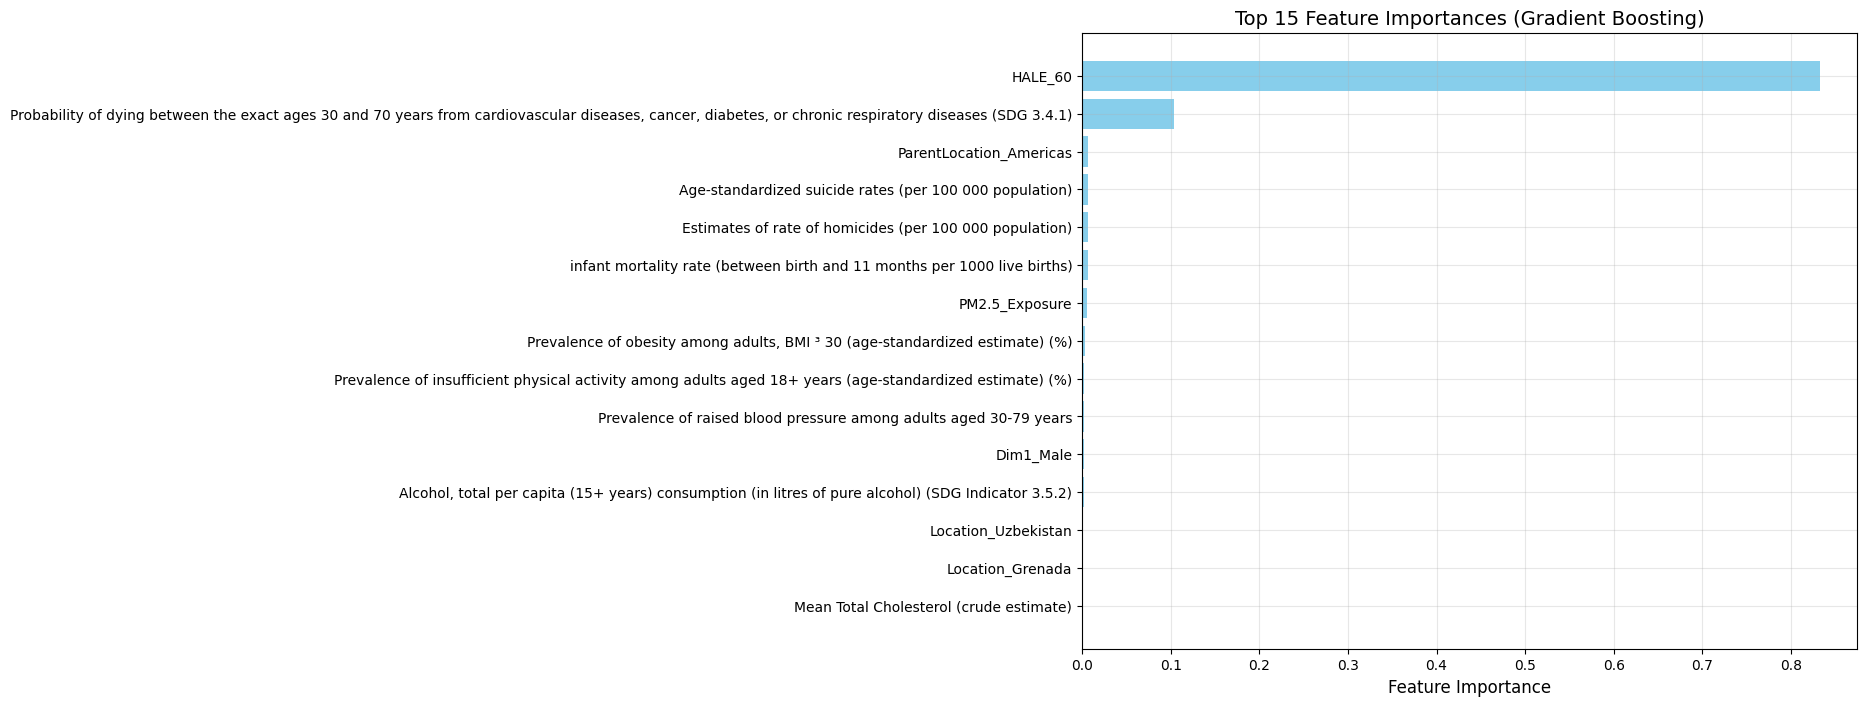


TOP 15 MOST IMPORTANT FEATURES (Gradient Boosting)
                                                                                                                                                Feature  Importance
                                                                                                                                                HALE_60    0.832986
Probability of dying between the exact ages 30 and 70 years from cardiovascular diseases, cancer, diabetes, or chronic respiratory diseases (SDG 3.4.1)    0.103716
                                                                                                                                ParentLocation_Americas    0.006875
                                                                                                Age-standardized suicide rates (per 100 000 population)    0.006835
                                                                                                Estimates of rate of homicides (

In [162]:
# ============= 9. MOST IMPORTANT VARIABLES (BEST MODEL) =============

# Find best model based on Test R²
best_model_name = max(model_results, key=lambda x: model_results[x]['Test R²'])
print(f"\n🏆 Best Model: {best_model_name} (Test R² = {model_results[best_model_name]['Test R²']:.4f})")

# Extract importance from best model
if best_model_name == 'Random Forest':
    best_model = rf_model
    importance = best_model.feature_importances_
    importance_type = "Feature Importance"
elif best_model_name == 'Gradient Boosting':
    best_model = gbr_model
    importance = best_model.feature_importances_
    importance_type = "Feature Importance"
elif best_model_name == 'Ridge Regression':
    best_model = ridge_model
    importance = np.abs(best_model.coef_)
    importance_type = "|Coefficient|"
else:
    importance = None
    importance_type = "Unknown"

# Feature importance plot for BEST model
plt.figure(figsize=(10, 8))

if importance is not None:
    feature_importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)
    
    plt.barh(feature_importance_df['Feature'][:15], feature_importance_df['Importance'][:15], color='skyblue')
    plt.title(f'Top 15 Feature Importances ({best_model_name})', fontsize=14)
    plt.xlabel(importance_type, fontsize=12)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Also print the values
    print("\n" + "="*50)
    print(f"TOP 15 MOST IMPORTANT FEATURES ({best_model_name})")
    print("="*50)
    print(feature_importance_df.head(15).to_string(index=False))
else:
    print(f"⚠️ Cannot extract feature importance for {best_model_name}")



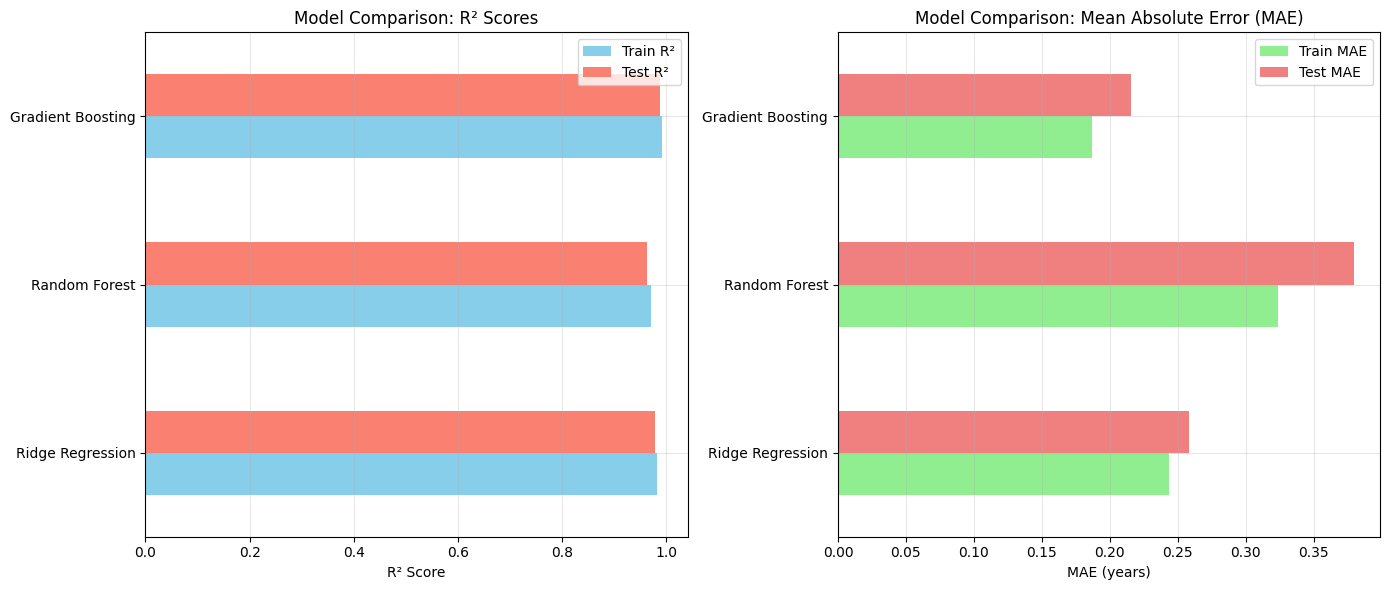

In [163]:
# ============= 10. Visualizations =============
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² comparison
comparison_df[['Train R²', 'Test R²']].plot(kind='barh', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Model Comparison: R² Scores')
axes[0].set_xlabel('R² Score')
axes[0].grid(True, alpha=0.3)

# MAE comparison
comparison_df[['Train MAE', 'Test MAE']].plot(kind='barh', ax=axes[1], color=['lightgreen', 'lightcoral'])
axes[1].set_title('Model Comparison: Mean Absolute Error (MAE)')
axes[1].set_xlabel('MAE (years)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [164]:
print("\n✅ Training and evaluation completed successfully!")


✅ Training and evaluation completed successfully!
